# MINTERPY/n-dimensional fitting for PCO FA CO2 neutral loss fragmentation data

## Packages and definitions

In [1]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

# others
import minterpy_functions as mf
import pickle

## PCO CO2 NL data fitting

In [2]:
# import FA anion fragment data via csv
df = pd.read_csv(r"./frag_data/211004_PCO_sn2CO2.csv").dropna(axis=1)
cols = ['CE', 'FA_C', 'FA_DB', 'FA_iso']

# analyte information to_numpy()
sample_points = df[cols].to_numpy()
function_vals = df['norm_Intensity'].to_numpy()

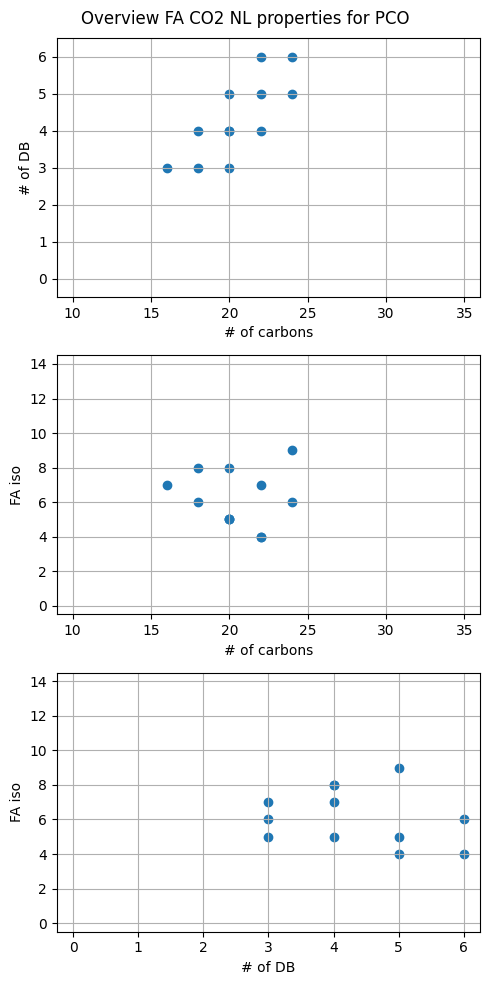

In [3]:
## get dataframe with needed properties
overview_df = df[['FA_C', 'FA_DB', 'FA_iso']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview FA CO2 NL properties for PCO')

# plot number of carbons vs number of DB
ax = plt.subplot(3,1,1)
plt.scatter(overview_df.FA_C, overview_df.FA_DB)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,6.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

# plot number of carbons vs DB position
ax = plt.subplot(3,1,2)
plt.scatter(overview_df.FA_C, overview_df.FA_iso)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')

# plot number of DB vs DB position
ax = plt.subplot(3,1,3)
plt.scatter(overview_df.FA_DB, overview_df.FA_iso)
ax.set_xlim(-0.25,6.25)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
plt.show()

In [4]:
a_uni = np.array(overview_df.sort_values(by=['FA_C', 'FA_DB', 'FA_iso']))
a_uni

array([[16,  3,  7],
       [18,  3,  6],
       [18,  4,  8],
       [20,  3,  5],
       [20,  4,  5],
       [20,  4,  8],
       [20,  5,  5],
       [22,  4,  7],
       [22,  5,  4],
       [22,  6,  4],
       [24,  5,  9],
       [24,  6,  6]])

Note:
- adding zero values or quasi zero values to the equation doesnt help; tested zero for 0DB and 2DB species
- removing extreme values from the like FA 18:4 would leed to more overfitting and data manipulation

## MINTERPY/n-dimensional fitting of PCO FA fragment data

In [5]:
sparse_poly_model = mf.lasso_fit_data(sample_points,
                                       function_vals, 
                                       poly_degree_along=[8,2,2,1], ## PCO FA with 8.3.2.2; degree could be lower here => no major changes
                                       weighted=True)

Optimizer result : 23.36280338513081


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/minterpy/schemes/barycentric/operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


L_2 error of fitting SYM dataset = 0.10595930640807213
L_inf error of fitting SYM dataset = 2.409754444537021


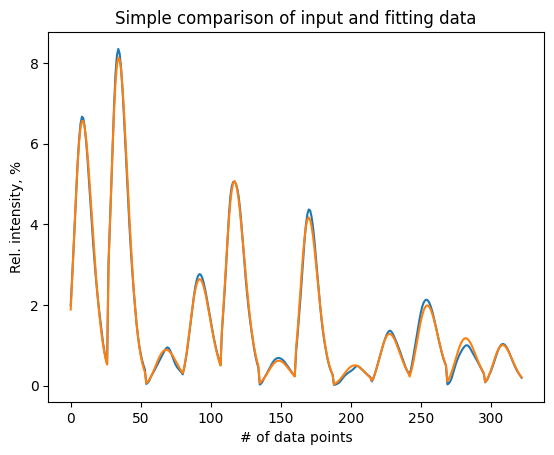

In [6]:
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model, sample_points, lower_bounds, upper_bounds)

abs_errs = pow(2,eval_vals) - function_vals
rel_errs = np.divide(abs_errs, function_vals)

L2_error = np.linalg.norm(rel_errs, 1)/len(rel_errs)
Linf_error = np.max(np.abs(rel_errs))

print(f"L_2 error of fitting SYM dataset = {L2_error}")
print(f"L_inf error of fitting SYM dataset = {Linf_error}")

plt.title("Simple comparison of input and fitting data")
plt.plot(function_vals)
plt.plot(pow(2,eval_vals))
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.show()

## Visualization of fitting data/results

### Comparison of fragment intensities : measured vs calculated via MINTERPY/ndim fitting

In [7]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'),
          ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'),
          ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

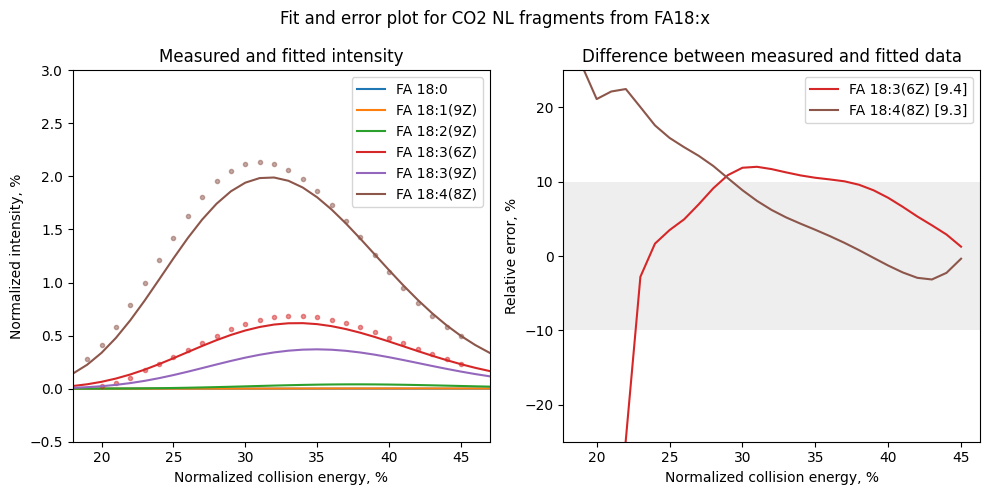

In [8]:
nce = [10,70] # range of nce
FA_oi = [[18, 0, 0], [18, 1, 9], [18, 2, 9], [18, 3, 6], [18, 3, 9], [18, 4, 8]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for CO2 NL fragments from FA18:x")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(18,47)
    ax[0].set_ylim(-0.5,3)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


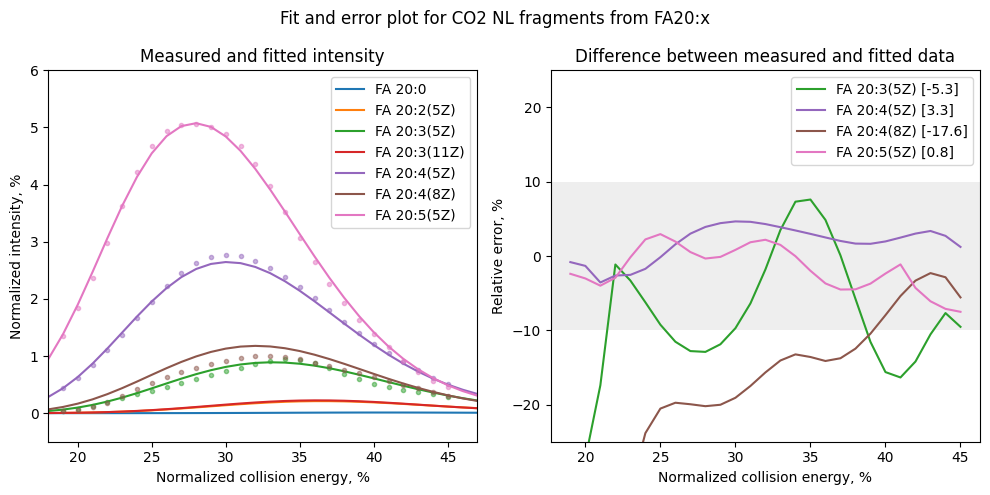

In [9]:
nce = [10,70] # range of nce
FA_oi = [[20, 0, 0], [20, 2, 5], [20, 3, 5], [20, 3, 11], [20, 4, 5], [20, 4, 8], [20, 5, 5]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for CO2 NL fragments from FA20:x")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(18,47)
    ax[0].set_ylim(-0.5,6)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


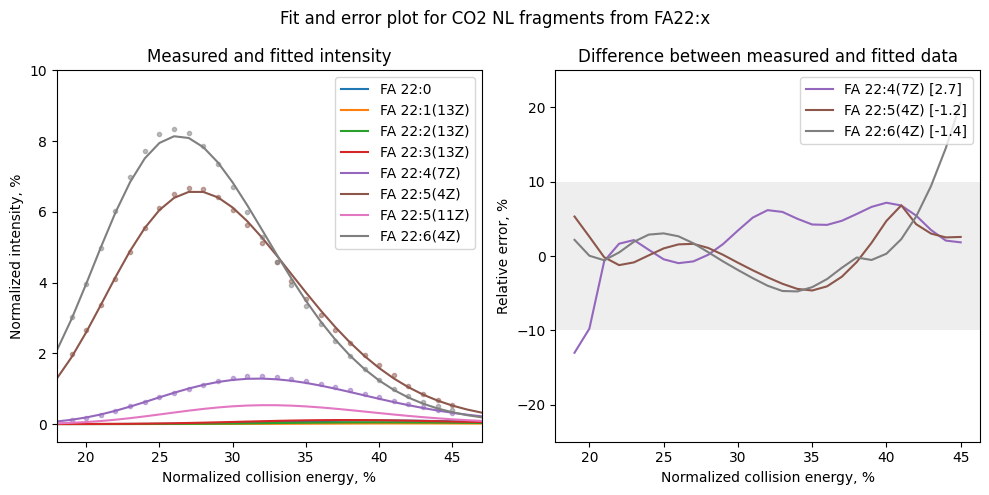

In [10]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 1, 13], [22, 2, 13], [22, 3, 13], [22, 4, 7], [22, 5, 4], [22, 5, 11], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for CO2 NL fragments from FA22:x")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(18,47)
    ax[0].set_ylim(-0.5,10)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

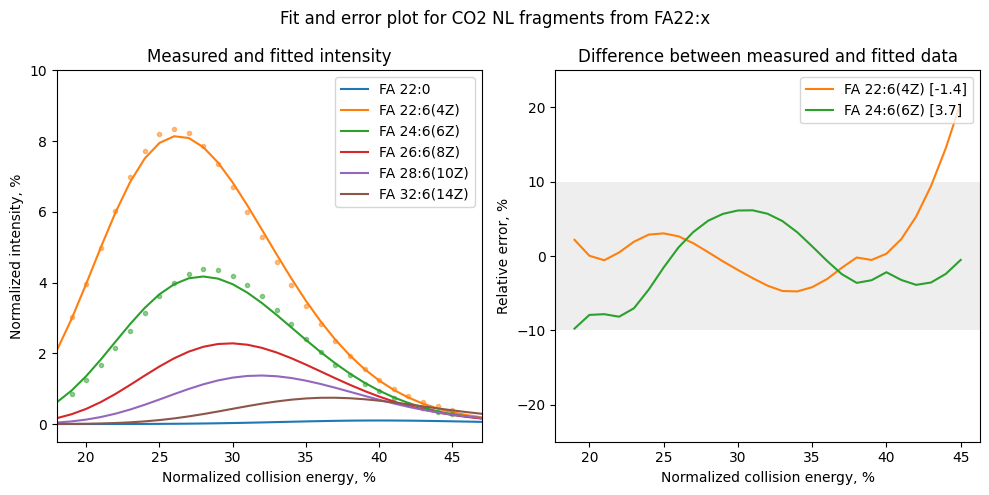

In [11]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for CO2 NL fragments from FA22:x")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(18,47)
    ax[0].set_ylim(-0.5,10)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Handling MINTERPYs ndim equations

### Convertion of NewtonPolynomials for 'equation' 

In [12]:
# Transformation of NewtonPolynomials to Canonical Form
model_can = mp.get_transformation(sparse_poly_model, mp.CanonicalPolynomial)()

trimmed_coeffs = model_can.coeffs.copy()

# conditional coefficient modification, if needed
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0
# trimmed_coeffs = np.around(trimmed_coeffs, 2)

model_can.coeffs = trimmed_coeffs
model_eqn = mf.mp_to_sympy(model_can)

# conversion to equation
model_eqn

Poly(-5.96451385808077e-15*x_0**8 + 1.28785870856519e-14*x_0**7*x_1**2*x_2**2*x_3 - 9.32587340685136e-15*x_0**7*x_1**2*x_2**2 + 3.59712259978552e-14*x_0**7*x_1**2*x_2*x_3 + 3.15303338993546e-14*x_0**7*x_1**2*x_2 - 7.91225903719205e-16*x_0**7*x_1**2*x_3 + 2.73279130829814e-14*x_0**7*x_1**2 - 1.3766765505352e-14*x_0**7*x_1*x_2**2*x_3 - 1.82076576038527e-14*x_0**7*x_1*x_2**2 + 9.32587340685132e-15*x_0**7*x_1*x_2*x_3 + 8.43769498715123e-15*x_0**7*x_1*x_2 - 3.55271367880054e-15*x_0**7*x_1*x_3 + 2.65605699311739e-15*x_0**7*x_1 + 9.19906939628853e-15*x_0**7*x_2**2*x_3 + 6.14683582480656e-18*x_0**7*x_2**2 - 5.40515169046302e-15*x_0**7*x_2*x_3 - 8.88178419700122e-15*x_0**7*x_2 - 1.10210717236866e-14*x_0**7*x_3 - 7.18968899780629e-14*x_0**7 - 7.43849426498862e-15*x_0**6*x_1**2*x_2**2*x_3 + 6.55031584528838e-15*x_0**6*x_1**2*x_2**2 + 1.44328993201258e-15*x_0**6*x_1**2*x_2*x_3 + 8.77076189453864e-15*x_0**6*x_1**2*x_2 + 1.99840144432528e-15*x_0**6*x_1**2*x_3 + 2.07671660852213e-15*x_0**6*x_1**2 + 4

### Convertion of 'equation' to NewtonPolynomials

In [13]:
# conversion of pco_model_eqn to new "sparse_poly_model" called "test_equation" to see if we get back intensity values
test_poly_model = mf.sympy_to_mp(model_eqn, target_basis=mp.NewtonPolynomial)

### Test of 'new' NewtonPolynomials

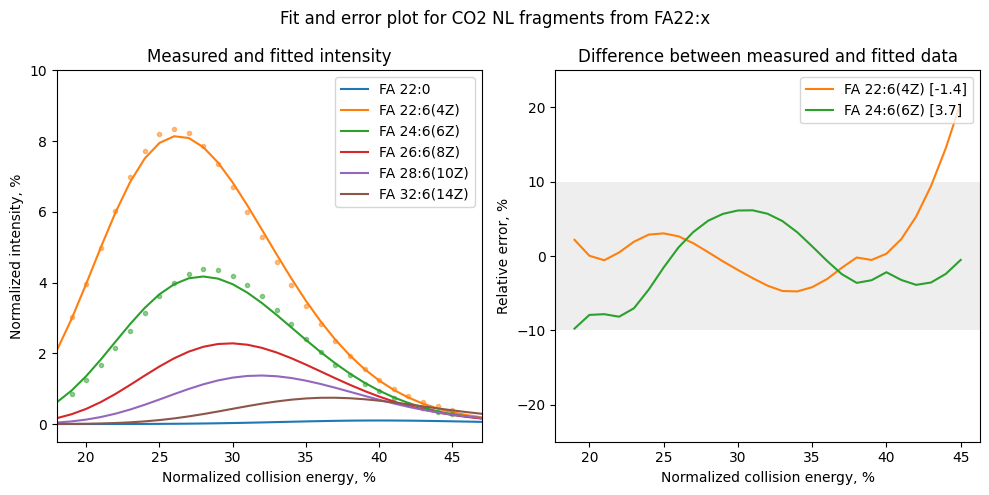

In [14]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for CO2 NL fragments from FA22:x")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(test_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(18,47)
    ax[0].set_ylim(-0.5,10)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Save the polynomial function as pickle

In [15]:
# write polynomial coefficients and exponents to dictionary for export
 
poly_info = {'coeffs': sparse_poly_model.coeffs, 'exponents': sparse_poly_model.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

## Storing the polynomial object in a file

pickle.dump(poly_info, open('./polynomials/240906_PCO_sn2CO2_poly.pkl', 'ab'))

In [16]:
poly_info

{'coeffs': array([-4.12153242e+00, -2.41624037e+00, -2.45055597e+00,  5.29152145e-01,
        -3.57811249e-01,  2.11739846e-01,  1.77635684e-14, -7.10542736e-14,
         0.00000000e+00,  7.59890581e-01,  1.21018739e-01, -2.49396664e-01,
         1.38904868e-01,  1.59872116e-14, -2.66453526e-14,  1.42108547e-14,
         1.77635684e-15,  9.83875479e-02, -4.57411886e-14,  7.54951657e-15,
        -6.25055563e-14,  9.76996262e-15, -4.79616347e-14,  2.13162821e-14,
         1.77635684e-15, -9.22717177e-01, -1.56897875e+00,  2.31793707e-02,
        -5.19584376e-14, -1.55431223e-14, -2.26485497e-14,  3.10862447e-15,
        -7.10542736e-15, -7.49400542e-15, -1.09634524e-14,  3.33066907e-15,
        -1.35447209e-14,  5.19029264e-15, -1.44328993e-14,  3.77475828e-15,
        -8.88178420e-16, -1.78745907e-14, -1.92623695e-14,  1.55431223e-15,
        -2.14828155e-14,  3.19189120e-15, -1.35447209e-14,  7.32747196e-15,
        -4.44089210e-15, -3.90387444e+00,  4.14701017e-01, -2.93833868e-01,
  

## Build CO2NL intensity template

### List of unique CO2NL features in PCO data set

In [17]:
pickle.dump(a_uni, open('./helper/CO2NL_items.pkl', 'ab'))

### Get fitted intensities for CO2NL items to generate CO2NL template

In [18]:
nce = [lower_bounds[0], upper_bounds[0]]
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

num_points_in_grid = int(upper_bounds[0] - lower_bounds[0])+1

data_l = []

for i in a_uni:
    C = i[0]
    DB = i[1]
    iso = i[2]
    
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,num_points_in_grid), i[0]) ## FA_C
    eval_points[:,2] = i[1]
    eval_points[:,3] = i[2]

    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)
    
    data = pd.DataFrame(eval_points)
    data_l.append(pd.concat([data, pd.Series(calc_intensity)], axis=1))

co2nl_template_df = pd.concat(data_l)

co2nl_template_df = co2nl_template_df.reset_index(drop=True)

co2nl_template_df.columns = ['CE', 'FA_C', 'FA_DB', 'FA_iso', 'norm_Intensity']

In [19]:
pickle.dump(co2nl_template_df, open('./helper/CO2NL_template.pkl', 'wb'))

## https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_json.html
## jason is possible, but need to specify the format first

# pco_template_df.to_json(r'pco_template_df.json', orient="table")
# result = pco_template_df.to_json(orient="table")
# parsed = json.loads(result)
# json.dumps(parsed)